In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix,classification_report

In [2]:
df = pd.read_csv('data\\vitamin_deficiency_disease_dataset_cleaned.csv')
df

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,vitamin_a_percent_rda,vitamin_c_percent_rda,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_dry_skin
0,79,Male,24.8,Former,Never,Active,Vegetarian,High,119.1,147.3,...,0,0,0,0,0,0,0,0,Healthy,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,85.7,57.5,...,0,0,0,1,0,0,0,0,Rickets_Osteomalacia,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,48.3,152.1,...,1,0,0,0,0,0,0,0,Healthy,1
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,75.8,51.0,...,0,0,0,0,0,1,1,0,Anemia,0
4,63,Male,29.6,Never,Never,Moderate,Vegetarian,Moderate,93.3,111.5,...,0,0,0,0,0,0,0,0,Healthy,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,25,Female,21.6,Former,Heavy,Active,Pescatarian,Moderate,41.4,66.1,...,1,0,0,0,0,0,0,0,Healthy,0
3996,50,Male,29.5,Former,Moderate,Sedentary,Vegetarian,Low,146.3,113.0,...,0,0,0,0,0,0,0,0,Healthy,0
3997,34,Female,24.8,Never,Never,Active,Pescatarian,Moderate,77.0,39.8,...,0,1,0,0,0,1,1,0,Anemia,0
3998,39,Female,26.9,Former,Heavy,Active,Omnivore,High,41.1,71.2,...,1,0,0,0,0,0,0,0,Anemia,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      4000 non-null   int64  
 1   gender                   4000 non-null   str    
 2   bmi                      4000 non-null   float64
 3   smoking_status           4000 non-null   str    
 4   alcohol_consumption      4000 non-null   str    
 5   exercise_level           4000 non-null   str    
 6   diet_type                4000 non-null   str    
 7   sun_exposure             4000 non-null   str    
 8   vitamin_a_percent_rda    4000 non-null   float64
 9   vitamin_c_percent_rda    4000 non-null   float64
 10  vitamin_d_percent_rda    4000 non-null   float64
 11  vitamin_e_percent_rda    4000 non-null   float64
 12  vitamin_b12_percent_rda  4000 non-null   float64
 13  folate_percent_rda       4000 non-null   float64
 14  calcium_percent_rda      4000 non-n

In [4]:
df.isnull().sum()

age                        0
gender                     0
bmi                        0
smoking_status             0
alcohol_consumption        0
exercise_level             0
diet_type                  0
sun_exposure               0
vitamin_a_percent_rda      0
vitamin_c_percent_rda      0
vitamin_d_percent_rda      0
vitamin_e_percent_rda      0
vitamin_b12_percent_rda    0
folate_percent_rda         0
calcium_percent_rda        0
iron_percent_rda           0
hemoglobin_g_dl            0
serum_vitamin_d_ng_ml      0
serum_vitamin_b12_pg_ml    0
serum_folate_ng_ml         0
has_night_blindness        0
has_fatigue                0
has_bleeding_gums          0
has_bone_pain              0
has_muscle_weakness        0
has_numbness_tingling      0
has_memory_problems        0
has_pale_skin              0
disease_diagnosis          0
has_dry_skin               0
dtype: int64

In [5]:
sns.set_palette('Set2')
sns.set_style('whitegrid')

<Figure size 3000x2000 with 0 Axes>

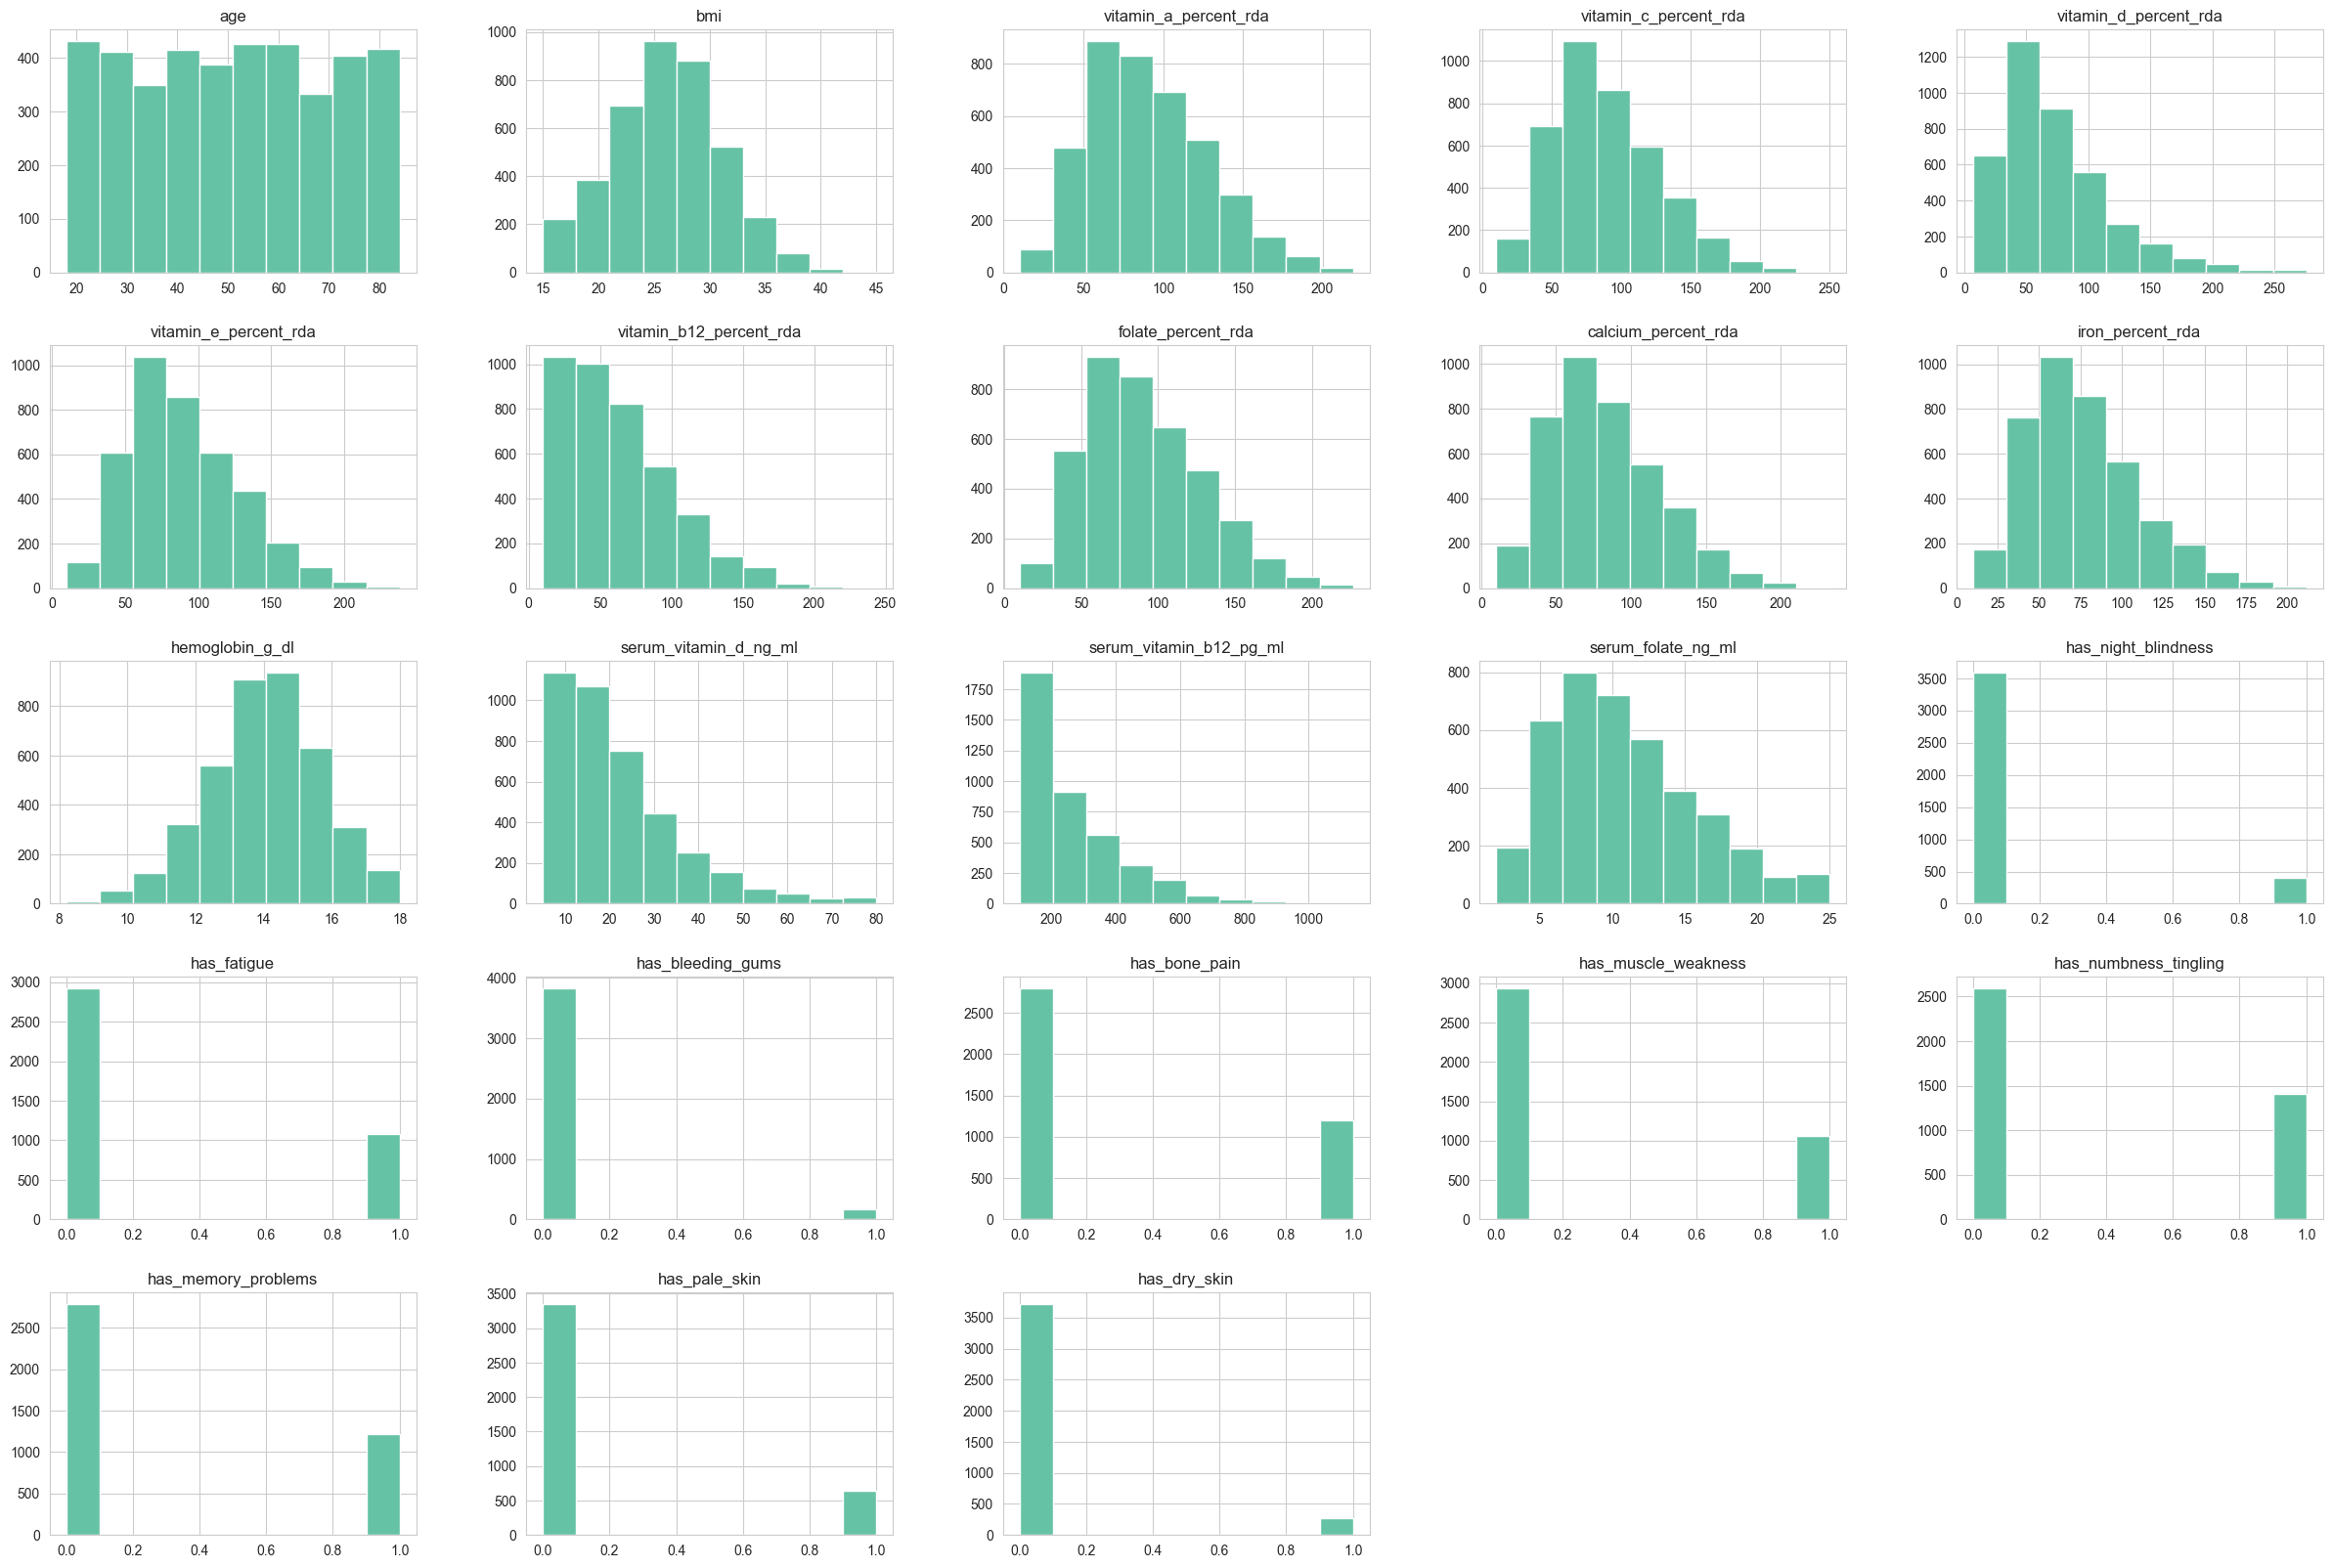

In [6]:
plt.figure(figsize=(30,20))
df.hist(figsize=(30,20))
plt.show()

In [7]:
df.select_dtypes(include=np.number).columns

Index(['age', 'bmi', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda',
       'vitamin_d_percent_rda', 'vitamin_e_percent_rda',
       'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda',
       'iron_percent_rda', 'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml',
       'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml', 'has_night_blindness',
       'has_fatigue', 'has_bleeding_gums', 'has_bone_pain',
       'has_muscle_weakness', 'has_numbness_tingling', 'has_memory_problems',
       'has_pale_skin', 'has_dry_skin'],
      dtype='str')

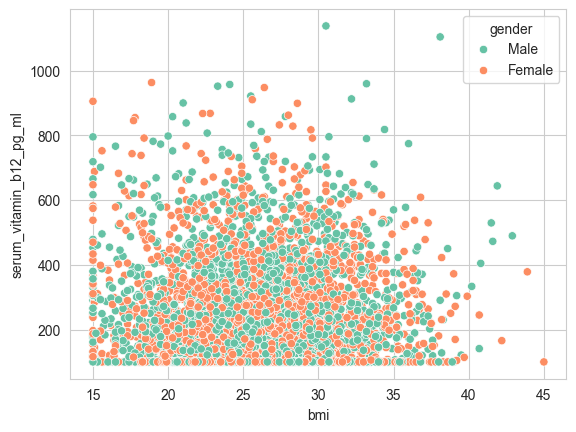

In [8]:
sns.scatterplot(data=df, x='bmi',y='serum_vitamin_b12_pg_ml',hue='gender')
plt.show()

In [9]:
num= df.select_dtypes(include=np.number)
corr = num.corr()

<Axes: >

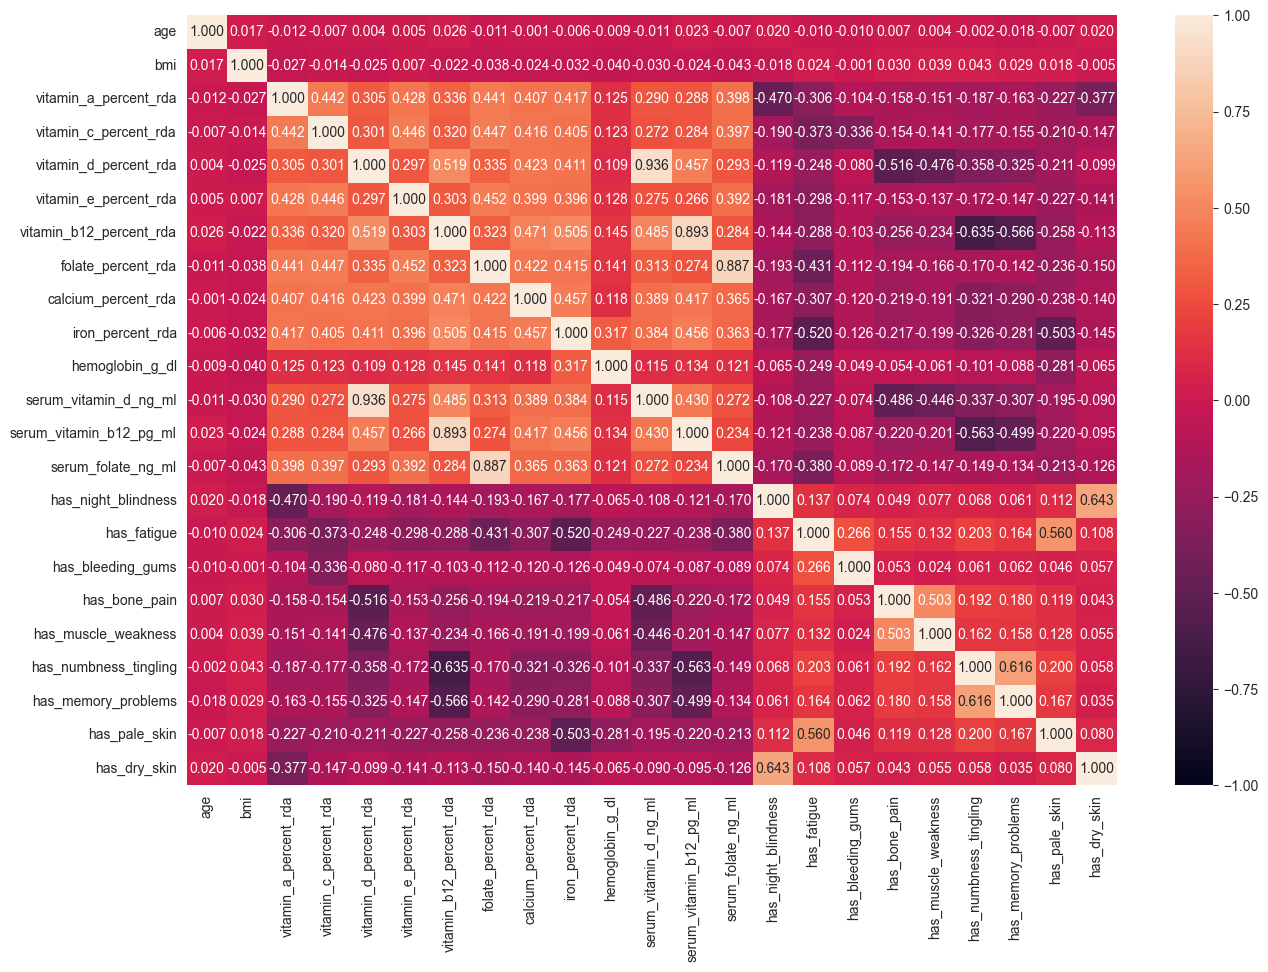

In [10]:
plt.figure(figsize=(15,10))
sns.heatmap(data=corr, annot=True,fmt=".3f",vmin=-1, vmax=1)

In [11]:
y = df.disease_diagnosis
y

0                    Healthy
1       Rickets_Osteomalacia
2                    Healthy
3                     Anemia
4                    Healthy
                ...         
3995                 Healthy
3996                 Healthy
3997                  Anemia
3998                  Anemia
3999                  Anemia
Name: disease_diagnosis, Length: 4000, dtype: str

In [12]:
X = df.drop(columns = ['disease_diagnosis'])
X

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,vitamin_a_percent_rda,vitamin_c_percent_rda,...,serum_folate_ng_ml,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,has_dry_skin
0,79,Male,24.8,Former,Never,Active,Vegetarian,High,119.1,147.3,...,23.3,0,0,0,0,0,0,0,0,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,85.7,57.5,...,5.3,0,0,0,1,0,0,0,0,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,48.3,152.1,...,16.3,1,0,0,0,0,0,0,0,1
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,75.8,51.0,...,9.2,0,0,0,0,0,1,1,0,0
4,63,Male,29.6,Never,Never,Moderate,Vegetarian,Moderate,93.3,111.5,...,13.4,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,25,Female,21.6,Former,Heavy,Active,Pescatarian,Moderate,41.4,66.1,...,9.2,1,0,0,0,0,0,0,0,0
3996,50,Male,29.5,Former,Moderate,Sedentary,Vegetarian,Low,146.3,113.0,...,15.0,0,0,0,0,0,0,0,0,0
3997,34,Female,24.8,Never,Never,Active,Pescatarian,Moderate,77.0,39.8,...,4.8,0,1,0,0,0,1,1,0,0
3998,39,Female,26.9,Former,Heavy,Active,Omnivore,High,41.1,71.2,...,6.1,1,0,0,0,0,0,0,0,1


In [13]:
le = LabelEncoder()
le.fit(y)

LabelEncoder()

In [14]:
y_classes = le.classes_

In [15]:
y = le.transform(y)
y

array([1, 3, 1, ..., 0, 0, 0], shape=(4000,))

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42, stratify = y)

In [17]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [18]:
scaler = StandardScaler()

In [19]:
cat_pipe = make_pipeline(encoder, scaler)

In [20]:
num_pipe = make_pipeline(scaler)

In [21]:
preprocess = make_column_transformer(
    (cat_pipe, make_column_selector(dtype_include=object)),
    (num_pipe, make_column_selector(dtype_include=np.number))
    
)

In [22]:
Lr = LogisticRegression()
tr = DecisionTreeClassifier(random_state=17)
knn = KNeighborsClassifier()
rc = RandomForestClassifier()

In [23]:
Lr_pipe = make_pipeline(preprocess, Lr)

In [24]:
Tr_pipe = make_pipeline(preprocess, tr)

In [25]:
knn_pipe = make_pipeline(preprocess, knn)

In [26]:
rc_pipe = make_pipeline(preprocess, rc)

In [27]:
title = 'CLASSIFICATION REPORT FOR'

****************************CLASSIFICATION REPORT FOR LOGISTICREGRESSION**************************** 
                      precision    recall  f1-score   support

              Anemia       0.93      0.87      0.90       996
             Healthy       0.92      0.97      0.95      1207
     Night_Blindness       0.70      0.58      0.63        98
Rickets_Osteomalacia       0.91      0.93      0.92       823
              Scurvy       0.55      0.55      0.55        76

            accuracy                           0.91      3200
           macro avg       0.80      0.78      0.79      3200
        weighted avg       0.91      0.91      0.91      3200



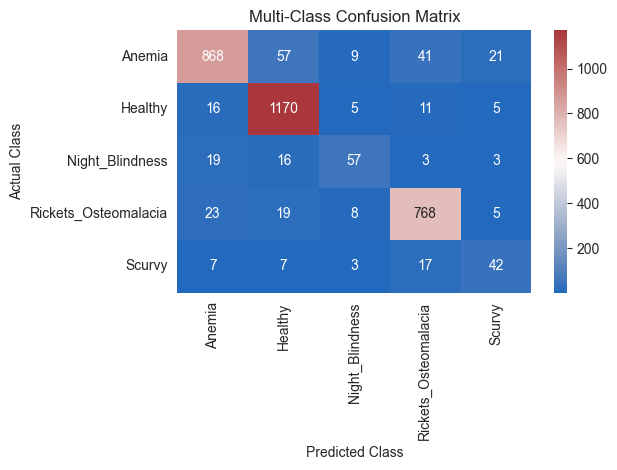

In [29]:
model_1 = "LogisticRegression"
Title_Lr = title + " " + model_1.upper()
clf_Lr = cross_val_predict(Lr_pipe, X_train, y_train, cv= 3)
print(f"{Title_Lr:*^100} ")
print(classification_report(y_true=y_train,y_pred=clf_Lr,target_names=y_classes))
cm_Lr = confusion_matrix(y_true=y_train, y_pred=clf_Lr)


sns.heatmap(
    cm_Lr, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

**************************CLASSIFICATION REPORT FOR DECISIONTREECLASSIFIER**************************
                      precision    recall  f1-score   support

              Anemia       0.99      0.99      0.99       996
             Healthy       0.99      0.99      0.99      1207
     Night_Blindness       0.92      0.94      0.93        98
Rickets_Osteomalacia       1.00      1.00      1.00       823
              Scurvy       0.99      0.89      0.94        76

            accuracy                           0.99      3200
           macro avg       0.98      0.96      0.97      3200
        weighted avg       0.99      0.99      0.99      3200



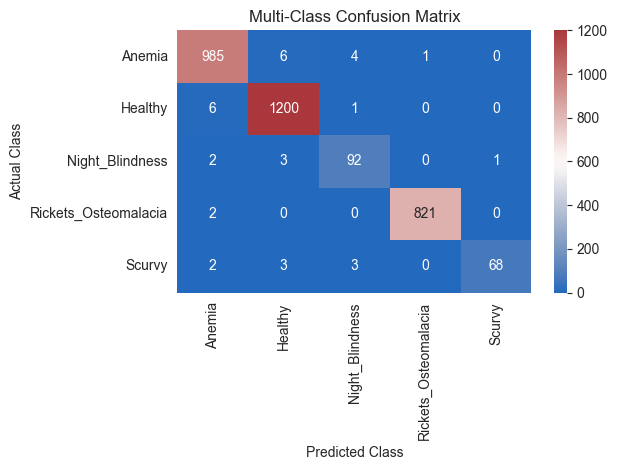

In [30]:
clf_tr = cross_val_predict(Tr_pipe, X_train, y_train, cv= 3)
model_2 = "DecisionTreeClassifier"
Title_tr = title + " " + model_2.upper()
cm_tr = confusion_matrix(y_train, clf_tr)
print(f"{Title_tr:*^100}")
print(classification_report(y_true=y_train,y_pred=clf_tr,target_names=y_classes))
cm_tr = confusion_matrix(y_true=y_train, y_pred=clf_tr)

sns.heatmap(
    cm_tr, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()


***************************CLASSIFICATION REPORT FOR KNEIGHBORSCLASSIFIER***************************
                      precision    recall  f1-score   support

              Anemia       0.74      0.69      0.72       996
             Healthy       0.76      0.92      0.83      1207
     Night_Blindness       0.41      0.12      0.19        98
Rickets_Osteomalacia       0.75      0.67      0.71       823
              Scurvy       0.45      0.26      0.33        76

            accuracy                           0.74      3200
           macro avg       0.62      0.53      0.56      3200
        weighted avg       0.73      0.74      0.73      3200



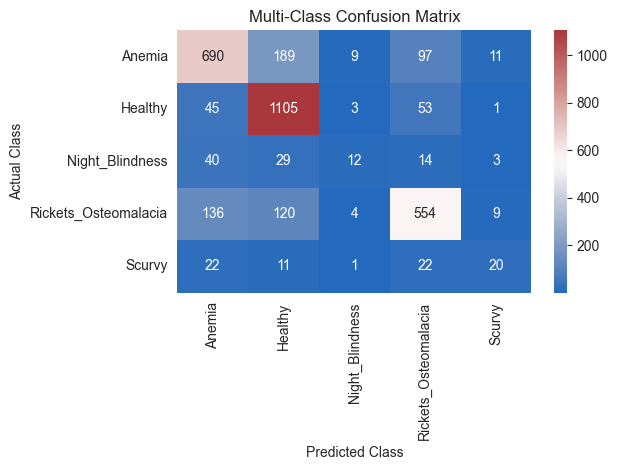

In [31]:
model_3 = "KNeighborsClassifier"
Title_knn = title + " " + model_3.upper()

clf_knn = cross_val_predict(knn_pipe, X_train, y_train, cv= 3)
print(f"{Title_knn:*^100}")
print(classification_report(y_true=y_train,y_pred=clf_knn,target_names=y_classes))
cm_knn = confusion_matrix(y_true=y_train, y_pred=clf_knn)

sns.heatmap(
    cm_knn, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

**************************CLASSIFICATION REPORT FOR RANDOMFORESTCLASSIFIER**************************
                      precision    recall  f1-score   support

              Anemia       0.96      1.00      0.98       996
             Healthy       0.99      0.99      0.99      1207
     Night_Blindness       0.96      0.79      0.87        98
Rickets_Osteomalacia       0.97      0.99      0.98       823
              Scurvy       1.00      0.47      0.64        76

            accuracy                           0.97      3200
           macro avg       0.98      0.85      0.89      3200
        weighted avg       0.98      0.97      0.97      3200



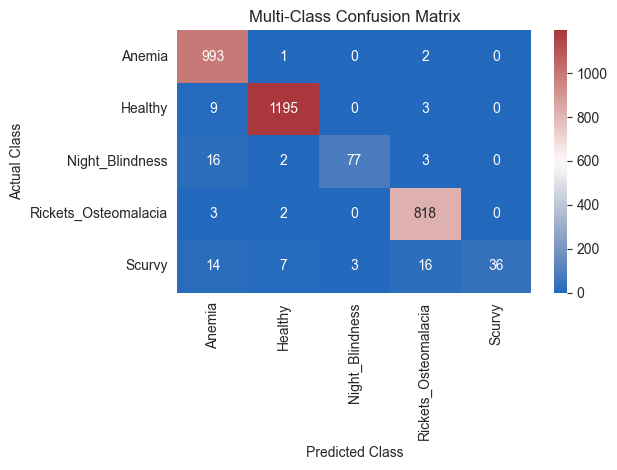

In [32]:
clf_rc = cross_val_predict(rc_pipe, X_train, y_train, cv= 3)
model_4 = "RandomForestClassifier"
Title_rc = title + " " + model_4.upper()
cm_rc = confusion_matrix(y_train, clf_rc)
print(f"{Title_rc:*^100}")
print(classification_report(y_true=y_train,y_pred=clf_rc,target_names=y_classes))
cm_rc = confusion_matrix(y_true=y_train, y_pred=clf_rc)

sns.heatmap(
    cm_rc, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()


In [33]:
model = Tr_pipe
model.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('pipeline-1',
                                    Pipeline(steps=[('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False)),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x000001F901762E40>),
                                   ('pipeline-2',
                                    Pipeline(steps=[('standardscaler',
                                                     StandardScaler())]),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x000001F90172AAD0>)])),
  ('decisiontreeclassifier', DecisionTreeClassifier(r

In [34]:
param = {
    'decisiontreeclassifier__criterion': ['gini', 'entropy'],
    'decisiontreeclassifier__max_depth': [None, 3, 5, 7, 10],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10],
    'decisiontreeclassifier__min_samples_leaf': [1, 2, 4],
    'decisiontreeclassifier__class_weight': [None, 'balanced'] # Added for single-label class balance
}
grid = GridSearchCV(estimator=model, param_grid=param, cv = 3, scoring='accuracy')

In [35]:
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=17))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decisiontreeclassifier__class_weight': [None, 'balanced'], 'decisiontreeclassifier__criterion': ['gini', 'entropy'], 'decisiontreeclassifier__max_depth': [None, 3, ...], 'decisiontreeclassifier__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose ver

In [36]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=17))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decisiontreeclassifier__class_weight': [None, 'balanced'], 'decisiontreeclassifier__criterion': ['gini', 'entropy'], 'decisiontreeclassifier__max_depth': [None, 3, ...], 'decisiontreeclassifier__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose ver

In [46]:
pd.DataFrame(grid.cv_results_).sort_values(by='mean_test_score', ascending= False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_decisiontreeclassifier__class_weight,param_decisiontreeclassifier__criterion,param_decisiontreeclassifier__max_depth,param_decisiontreeclassifier__min_samples_leaf,param_decisiontreeclassifier__min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
138,0.034555,0.002936,0.004008,0.000668,balanced,entropy,None,2,2,{'decisiontreeclassifier__class_weight': 'bala...,0.996251,0.990628,0.995310,0.994063,0.002459,1
174,0.028693,0.003560,0.002832,0.000600,balanced,entropy,10,2,2,{'decisiontreeclassifier__class_weight': 'bala...,0.996251,0.990628,0.995310,0.994063,0.002459,1
127,0.024379,0.003253,0.003426,0.000153,balanced,gini,10,1,5,{'decisiontreeclassifier__class_weight': 'bala...,0.995314,0.989691,0.996248,0.993751,0.002896,3
171,0.027849,0.007729,0.003827,0.001098,balanced,entropy,10,1,2,{'decisiontreeclassifier__class_weight': 'bala...,0.996251,0.988754,0.996248,0.993751,0.003534,3
91,0.027145,0.001642,0.003935,0.000653,balanced,gini,None,1,5,{'decisiontreeclassifier__class_weight': 'bala...,0.995314,0.989691,0.996248,0.993751,0.002896,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,0.017999,0.000192,0.004874,0.001581,balanced,gini,3,2,2,{'decisiontreeclassifier__class_weight': 'bala...,0.668229,0.668229,0.666979,0.667812,0.000589,172
103,0.020187,0.005625,0.004289,0.001894,balanced,gini,3,2,5,{'decisiontreeclassifier__class_weight': 'bala...,0.668229,0.668229,0.666979,0.667812,0.000589,172
104,0.015869,0.001807,0.004843,0.000729,balanced,gini,3,2,10,{'decisiontreeclassifier__class_weight': 'bala...,0.668229,0.668229,0.666979,0.667812,0.000589,172
107,0.019450,0.002691,0.004165,0.000976,balanced,gini,3,4,10,{'decisiontreeclassifier__class_weight': 'bala...,0.668229,0.668229,0.666979,0.667812,0.000589,172


In [37]:
finished_model = grid.best_estimator_

In [38]:
finished_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the out

In [39]:
pred = finished_model.predict(X_test)

In [40]:
count = 0
predicted = (pred == y_test)
for i in predicted:
    if not i:
        count += 1

In [41]:
if all(predicted):
    print('Yes')
else:
    if count == 1:
        print(f'{count} is False')
    else:
        print(f"{count} are False")
    

3 are False


In [42]:
import joblib

# 1. Saving the final trained pipeline model
joblib.dump(finished_model, 'model.pkl')


# Target classes are: ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']
joblib.dump(y_classes, 'classes.pkl')

print("Model assets successfully exported for deployment!")


Model assets successfully exported for deployment!
